### HuyIGW04 - Logistic Regression - PyTorch  - M05W02

In [23]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

### Traditional

In [24]:
data = np.genfromtxt('iris_full.csv', delimiter=',', skip_header=True)
X = torch.tensor(data[:, :-1]).float().to('cuda')
y = torch.tensor(data[:, -1:]).float().to('cuda')
print(X.shape, y.shape)

torch.Size([100, 4]) torch.Size([100, 1])


In [25]:
input_feature = X.shape[1]

# constructor
loss = nn.BCELoss()

# model
model = nn.Sequential(
    nn.Linear(input_feature, 1)
).to('cuda')

# stochastic GD
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# batch training
epochs = 1000
losses = []

for epoch in range(epochs):
    y_hat = torch.sigmoid(model(X))
    loss_epoch = loss(y_hat, y)
    losses.append(loss_epoch.item())
    optimizer.zero_grad()
    loss_epoch.backward()
    optimizer.step()

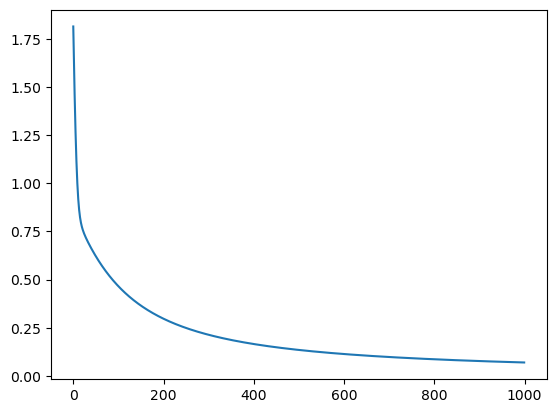

In [26]:
plt.plot(losses)

In [27]:
print("X.is_cuda:", X.is_cuda)           
print("y_hat.is_cuda:", y_hat.is_cuda)   


X.is_cuda: True
y_hat.is_cuda: True


### Binary Cross Entropy with Logits

In [28]:
X_new = torch.tensor(data[:, :-1]).float().to('cuda')
y_new = torch.tensor(data[:, -1:]).float().to('cuda')

print(X_new.shape, y_new.shape)

torch.Size([100, 4]) torch.Size([100, 1])


In [ ]:
N = X_new.shape[1]
model = nn.Sequential(
    nn.Linear(N, 1)
).to('cuda')

# new loss
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

epochs = 1000
new_losses = []

for epoch in range(epochs):
    # compute logits
    y_hat = model(X)

    # compute loss BCE + Logit
    loss_epoch = loss(y_hat, y)
    new_losses.append(loss_epoch.item())

    # autograd
    optimizer.zero_grad()
    loss_epoch.backward()

    # optimize weight
    optimizer.step()

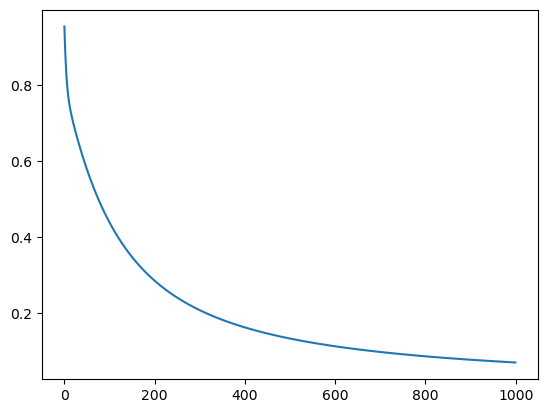

In [30]:
plt.plot(new_losses)

In [ ]:
# BCE with Logits is better than BCE traditional
print(losses[-1])
print(new_losses[-1])

0.06998273730278015
0.06914842128753662
